In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from figutils import cm, set_figure_style

set_figure_style()

ROOT       = ".."
FOLDS_DIR  = os.path.join(ROOT, "data", "prep", "finetuning", "alphagenome")
OUTPUT_DIR = os.path.join("pdfs", "fold_pangolin_overlap")
os.makedirs(OUTPUT_DIR, exist_ok=True)

ALPHAGENOME_FOLDS = ["FOLD_0", "FOLD_1", "FOLD_2", "FOLD_3"]
SPLITS            = ["test", "valid"]

# Pangolin uses a chromosome-based split (from Pangolin_train/preprocessing/create_datafile.py)
PANGOLIN_TEST_CHROMS  = {"chr1", "chr3", "chr5", "chr7", "chr9"}
PANGOLIN_TRAIN_CHROMS = {
    "chr2", "chr4", "chr6", "chr8", "chr10", "chr11", "chr12", "chr13",
    "chr14", "chr15", "chr16", "chr17", "chr18", "chr19", "chr20", "chr21",
    "chr22", "chrX", "chrY",
}
# Pangolin val is a random 10% of genes on training chromosomes — no fixed genomic positions
print("Pangolin test chroms: ", sorted(PANGOLIN_TEST_CHROMS))
print("Pangolin train chroms:", sorted(PANGOLIN_TRAIN_CHROMS))

Pangolin test chroms:  ['chr1', 'chr3', 'chr5', 'chr7', 'chr9']
Pangolin train chroms: ['chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr4', 'chr6', 'chr8', 'chrX', 'chrY']


## Background

**Pangolin** uses a chromosome-based train/test split:
- **Test**: chr1, chr3, chr5, chr7, chr9
- **Train**: all other autosomes + chrX + chrY
- **Val**: random 10% of genes on training chromosomes (no fixed positions)

**AlphaGenome** has 4 folds (FOLD_0–FOLD_3), each defined by 1 Mb BED intervals derived from Borzoi folds. The mapping is:

| AlphaGenome fold | Borzoi valid | Borzoi test |
|------------------|-------------|-------------|
| FOLD_0           | fold0       | fold1       |
| FOLD_1           | fold3       | fold4       |
| FOLD_2           | fold2       | fold5       |
| FOLD_3           | fold6       | fold7       |

**Goal**: find which AlphaGenome fold's **test** and **valid** intervals overlap the most with Pangolin's **test chromosomes** (chr1, chr3, chr5, chr7, chr9). High overlap means both models are evaluated on equivalent genomic territory.

## 1. Load all fold BED files

In [2]:
records = []
for fold in ALPHAGENOME_FOLDS:
    for split in SPLITS + ["train"]:
        path = os.path.join(FOLDS_DIR, fold, f"{split}.bed")
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue
        df = pd.read_csv(path, sep="\t", header=None, names=["chrom", "start", "end"])
        df["fold"]  = fold
        df["split"] = split
        records.append(df)

beds = pd.concat(records, ignore_index=True)
beds["length_mb"] = (beds["end"] - beds["start"]) / 1e6
print(beds.groupby(["fold", "split"]).size().unstack(fill_value=0))

split   test  train  valid
fold                      
FOLD_0  6086  41694   6452
FOLD_1  6359  41699   6323
FOLD_2  6387  41977   5885
FOLD_3  6355  41121   6909


## 2. Classify each interval by Pangolin chromosome group

In [3]:
def pangolin_group(chrom):
    if chrom in PANGOLIN_TEST_CHROMS:
        return "pangolin_test"
    elif chrom in PANGOLIN_TRAIN_CHROMS:
        return "pangolin_train"
    else:
        return "other"

beds["pangolin_group"] = beds["chrom"].map(pangolin_group)
beds.groupby(["fold", "split", "pangolin_group"]).size().unstack(fill_value=0)

pangolin_group  pangolin_test  pangolin_train
fold   split                                 
FOLD_0 test               777            5309
       train            13918           27776
       valid             2029            4423
FOLD_1 test              1316            5043
       train            13389           28310
       valid             2022            4301
FOLD_2 test              2571            3816
       train            13063           28914
       valid             1150            4735
FOLD_3 test              4989            1366
       train            10753           30368
       valid              981            5928

## 3. Fraction of test/valid intervals on Pangolin test chromosomes

In [4]:
eval_splits = beds[beds["split"].isin(["test", "valid"])].copy()

counts = (
    eval_splits
    .groupby(["fold", "split", "pangolin_group"])
    .size()
    .reset_index(name="n")
)
totals = counts.groupby(["fold", "split"])["n"].sum().reset_index(name="total")
counts = counts.merge(totals, on=["fold", "split"])
counts["frac"] = counts["n"] / counts["total"]

overlap = counts[counts["pangolin_group"] == "pangolin_test"].copy()
overlap = overlap.pivot(index="fold", columns="split", values="frac")
print(overlap.round(3))

split    test  valid
fold                
FOLD_0  0.128  0.314
FOLD_1  0.207  0.320
FOLD_2  0.403  0.195
FOLD_3  0.785  0.142


## 4. Heatmap — fraction of AlphaGenome eval intervals on Pangolin test chromosomes

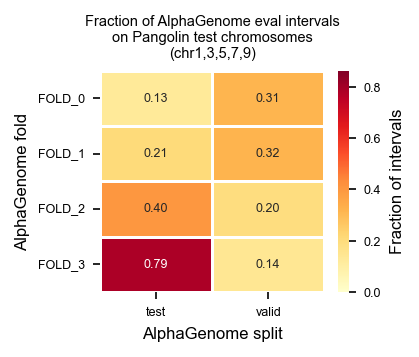

In [5]:
fig, ax = plt.subplots(figsize=(7*cm, 6*cm))
sns.heatmap(
    overlap[["test", "valid"]],
    annot=True, fmt=".2f", cmap="YlOrRd",
    vmin=0, vmax=overlap.values.max() * 1.1,
    linewidths=0.5, ax=ax,
    cbar_kws={"label": "Fraction of intervals"},
)
ax.set_title("Fraction of AlphaGenome eval intervals\non Pangolin test chromosomes\n(chr1,3,5,7,9)", fontsize=7)
ax.set_xlabel("AlphaGenome split")
ax.set_ylabel("AlphaGenome fold")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "heatmap_pangolin_overlap_fraction.pdf"))
plt.show()

## 5. Chromosome-level breakdown for each fold's test and valid intervals

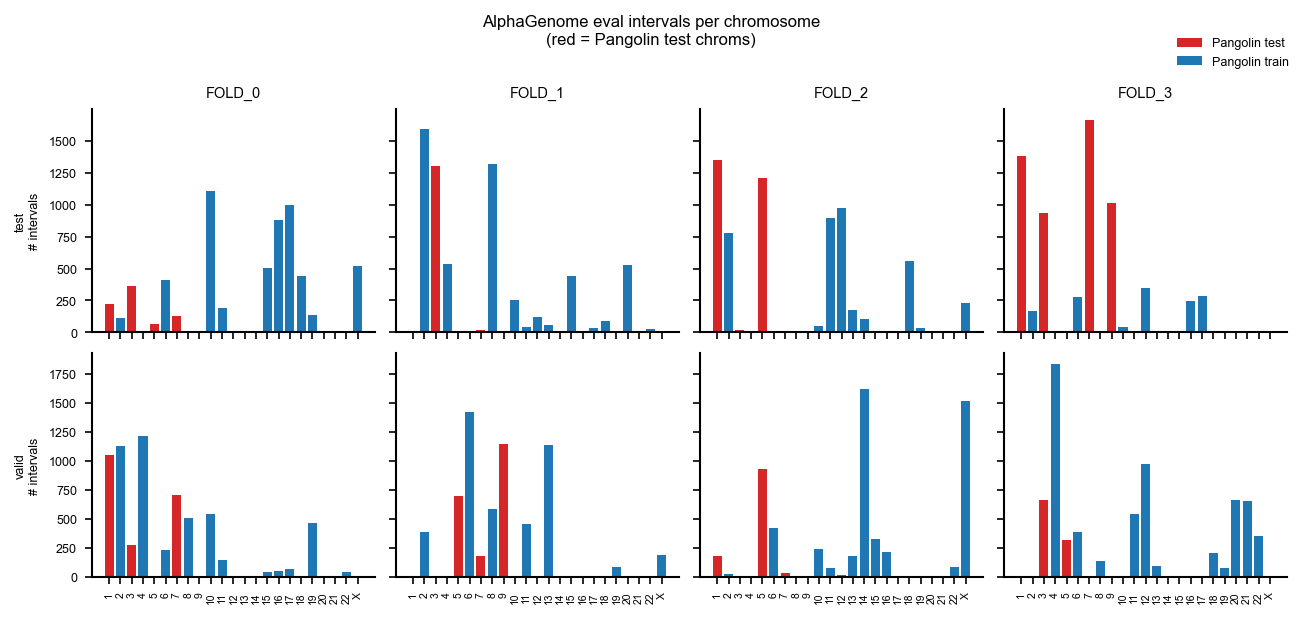

In [6]:
chrom_counts = (
    eval_splits
    .groupby(["fold", "split", "chrom"])
    .size()
    .reset_index(name="n_intervals")
)

# Natural chromosome sort order
def chrom_sort_key(c):
    c = c.replace("chr", "")
    return (0, int(c)) if c.isdigit() else (1, c)

all_chroms = sorted(chrom_counts["chrom"].unique(), key=chrom_sort_key)

fig, axes = plt.subplots(
    len(SPLITS), len(ALPHAGENOME_FOLDS),
    figsize=(22*cm, 10*cm), sharex=True, sharey="row"
)

for row_i, split in enumerate(SPLITS):
    for col_i, fold in enumerate(ALPHAGENOME_FOLDS):
        ax = axes[row_i, col_i]
        sub = chrom_counts[(chrom_counts["fold"] == fold) & (chrom_counts["split"] == split)]
        sub = sub.set_index("chrom").reindex(all_chroms, fill_value=0).reset_index()
        colors = [
            "#d62728" if c in PANGOLIN_TEST_CHROMS else "#1f77b4"
            for c in sub["chrom"]
        ]
        ax.bar(range(len(sub)), sub["n_intervals"], color=colors, width=0.8)
        ax.set_xticks(range(len(sub)))
        ax.set_xticklabels(
            [c.replace("chr", "") for c in sub["chrom"]],
            rotation=90, fontsize=5
        )
        if col_i == 0:
            ax.set_ylabel(f"{split}\n# intervals", fontsize=6)
        if row_i == 0:
            ax.set_title(fold, fontsize=7)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#d62728", label="Pangolin test"),
    Patch(facecolor="#1f77b4", label="Pangolin train"),
]
fig.legend(
    handles=legend_elements, loc="upper right",
    frameon=False, fontsize=6, bbox_to_anchor=(1.0, 1.0)
)
fig.suptitle(
    "AlphaGenome eval intervals per chromosome\n(red = Pangolin test chroms)",
    fontsize=8, y=1.02
)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "chrom_breakdown_per_fold.pdf"), bbox_inches="tight")
plt.show()

## 6. Absolute number of intervals on Pangolin test chromosomes (test + valid combined)

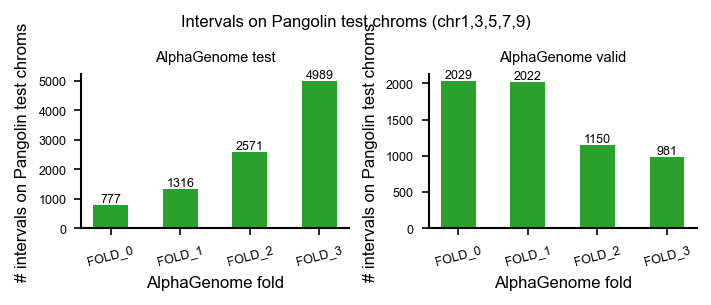

In [7]:
abs_overlap = (
    eval_splits[eval_splits["pangolin_group"] == "pangolin_test"]
    .groupby(["fold", "split"])
    .size()
    .reset_index(name="n_on_pangolin_test_chroms")
)

fig, axes = plt.subplots(1, 2, figsize=(12*cm, 5*cm), sharey=False)

for ax, split in zip(axes, SPLITS):
    sub = abs_overlap[abs_overlap["split"] == split]
    bars = ax.bar(sub["fold"], sub["n_on_pangolin_test_chroms"], color="#2ca02c", width=0.5)
    ax.bar_label(bars, fontsize=6)
    ax.set_title(f"AlphaGenome {split}", fontsize=7)
    ax.set_xlabel("AlphaGenome fold")
    ax.set_ylabel("# intervals on Pangolin test chroms")
    ax.tick_params(axis="x", rotation=15)

fig.suptitle("Intervals on Pangolin test chroms (chr1,3,5,7,9)", fontsize=8)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "absolute_overlap_per_fold.pdf"))
plt.show()

## 7. Summary — which fold to use for Pangolin-comparable evaluation

In [8]:
# Combined score: sum of test + valid fractions on Pangolin test chroms
combined = (
    overlap[["test", "valid"]]
    .assign(combined=lambda d: d["test"] + d["valid"])
    .sort_values("combined", ascending=False)
)

print("Overlap fraction with Pangolin test chromosomes (chr1,3,5,7,9):")
print(combined.round(3).to_string())
print()
best = combined.index[0]
print(f"Best fold for Pangolin-comparable evaluation: {best}")
print(f"  test  fraction: {overlap.loc[best, 'test']:.3f}")
print(f"  valid fraction: {overlap.loc[best, 'valid']:.3f}")

Overlap fraction with Pangolin test chromosomes (chr1,3,5,7,9):
split    test  valid  combined
fold                          
FOLD_3  0.785  0.142     0.927
FOLD_2  0.403  0.195     0.598
FOLD_1  0.207  0.320     0.527
FOLD_0  0.128  0.314     0.442

Best fold for Pangolin-comparable evaluation: FOLD_3
  test  fraction: 0.785
  valid fraction: 0.142
